In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
def plot_execution_time(json_data):
    dfj_times, mtz_times = {}, {}

    for full_run in json_data.values():
        for execution in full_run:
            n = execution["n"]

            if n not in dfj_times:
                dfj_times[n] = []
                mtz_times[n] = []

            dfj_times[n].append(execution["dfj_time_ms"])
            mtz_times[n].append(execution["mtz_time_ms"])

    x_values = sorted(dfj_times.keys())

    dfj_avg = [sum(dfj_times[n]) / len(dfj_times[n]) for n in x_values]
    mtz_avg = [sum(mtz_times[n]) / len(mtz_times[n]) for n in x_values]

    plt.figure(figsize=(10, 6))

    plt.plot(x_values, dfj_avg, marker="o", label="DFJ average")
    plt.plot(x_values, mtz_avg, marker="o", label="MTZ average")

    plt.xlabel("Number of nodes (n)")
    plt.ylabel("Average execution time (ms)")
    plt.title("Average Execution Time Comparison: DFJ vs MTZ")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

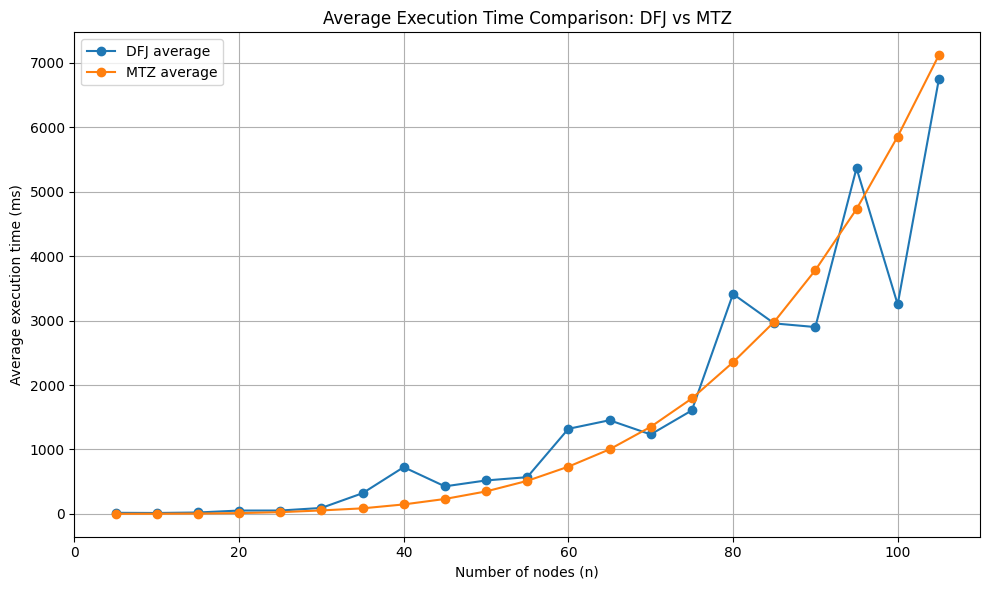

In [3]:
data_dir = Path("")

json_data = {}

for file in data_dir.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        json_data[str(file)] = json.load(f)

plot_execution_time(json_data)